# Customer Churn Prediction using Machine Learning


Dataset: Telco Customer Churn (IBM, extended version with geography/CLTV/Churn Score)

## Task 1: Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import torch
import torch.nn as nn

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


In [2]:
df = pd.read_excel('Telco_Churn.xlsx')
print(df.shape)
df.head()


(7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTotalCharges dtype:", df['Total Charges'].dtype)


Churn Reason    5174
dtype: int64

Duplicate rows: 0

TotalCharges dtype: object


**Columns dropped, and why:**
- `CustomerID`, `Count`, `Country`, `State`, `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude` — identifiers or geography that's either constant (all rows are "United States"/"California") or too high-cardinality (1,129 distinct cities) to generalize from.
- `Churn Label` — kept `Churn Value` instead (same information, already 0/1).
- **`Churn Score`** — this is IBM's own precomputed churn-propensity score. Using it as a feature would leak the answer straight into the model.
- **`Churn Reason`** — only populated *after* a customer has churned, so it directly encodes the target. Also dropped as leakage.
- `CLTV` (Customer Lifetime Value) — kept. This is a legitimate business metric known before churn, not leakage.

In [4]:
leak_and_id_cols = ['CustomerID','Count','Country','State','City','Zip Code',
                     'Lat Long','Latitude','Longitude','Churn Label',
                     'Churn Score','Churn Reason']
df = df.drop(columns=leak_and_id_cols)
df = df.rename(columns={'Churn Value':'Churn'})
print(df.shape)
df.columns.tolist()


(7043, 21)


['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn',
 'CLTV']

In [5]:
# Total Charges has the same hidden-blank issue as before (new customers, tenure=0)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print("Missing Total Charges after conversion:", df['Total Charges'].isnull().sum())
df.loc[df['Total Charges'].isnull(), ['Tenure Months','Monthly Charges']]


Missing Total Charges after conversion: 11


,Tenure Months,Monthly Charges
2234,0,52.55
2438,0,20.25
2568,0,80.85
2667,0,25.75
2856,0,56.05
4331,0,19.85
4687,0,25.35
5104,0,20.00
5719,0,19.70
6772,0,73.35


In [6]:
df['Total Charges'] = df['Total Charges'].fillna(0)
df['Churn'].value_counts(normalize=True)


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [7]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = ['Tenure Months','Monthly Charges','Total Charges','CLTV']
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)


Categorical columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical columns: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


/tmp/ipykernel_517/2286993621.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [8]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)


Shape after encoding: (7043, 32)


In [9]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), " Test churn rate:", y_test.mean().round(3))


Train shape: (5634, 31)  Test shape: (1409, 31)
Train churn rate: 0.265  Test churn rate: 0.265


## Task 2: Exploratory Data Analysis

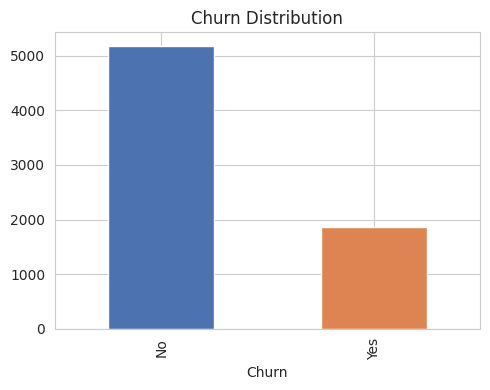

In [10]:
fig, ax = plt.subplots(figsize=(5,4))
df['Churn'].map({0:'No',1:'Yes'}).value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'], ax=ax)
ax.set_title('Churn Distribution')
plt.tight_layout(); plt.show()


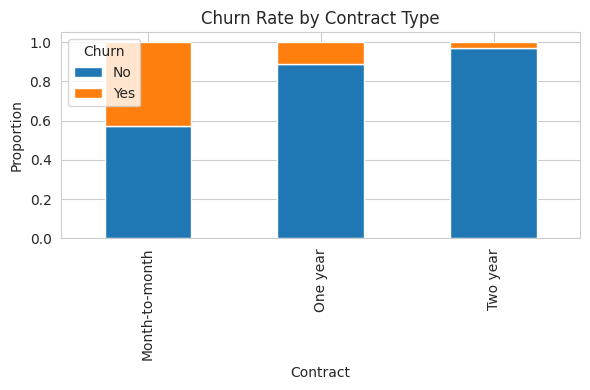

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
pd.crosstab(df['Contract'], df['Churn'].map({0:'No',1:'Yes'}), normalize='index').plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Proportion')
plt.tight_layout(); plt.show()


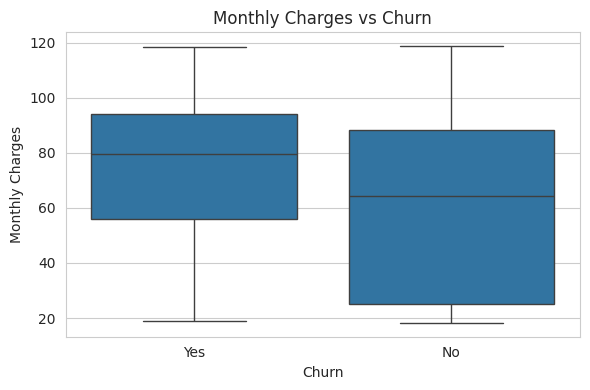

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x='Churn', y='Monthly Charges', data=df.assign(Churn=df['Churn'].map({0:'No',1:'Yes'})), ax=ax)
ax.set_title('Monthly Charges vs Churn')
plt.tight_layout(); plt.show()


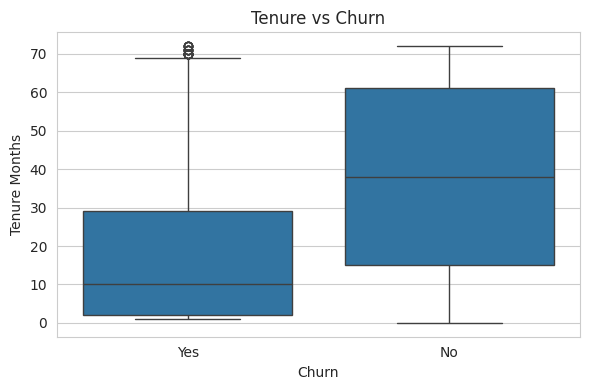

In [13]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x='Churn', y='Tenure Months', data=df.assign(Churn=df['Churn'].map({0:'No',1:'Yes'})), ax=ax)
ax.set_title('Tenure vs Churn')
plt.tight_layout(); plt.show()


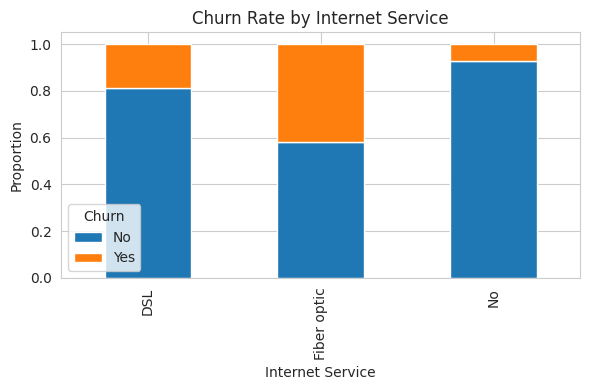

In [14]:
fig, ax = plt.subplots(figsize=(6,4))
pd.crosstab(df['Internet Service'], df['Churn'].map({0:'No',1:'Yes'}), normalize='index').plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Churn Rate by Internet Service')
ax.set_ylabel('Proportion')
plt.tight_layout(); plt.show()


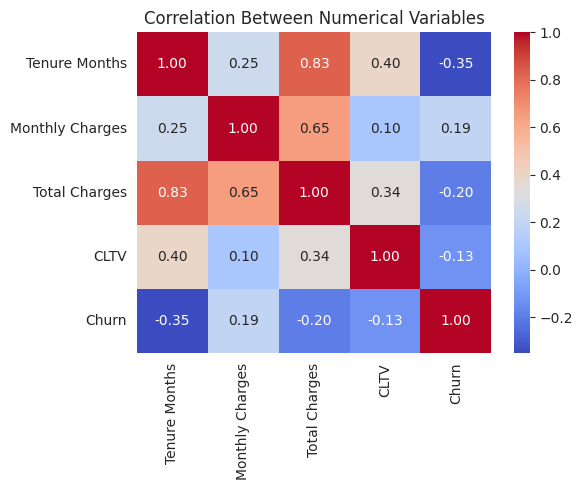

In [15]:
fig, ax = plt.subplots(figsize=(6,5))
corr = df[['Tenure Months','Monthly Charges','Total Charges','CLTV','Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Between Numerical Variables')
plt.tight_layout(); plt.show()


**Observations:** (to be confirmed against the executed output below)
- Churn is imbalanced.
- Month-to-month contracts churn more than annual contracts.
- Churned customers tend to have higher Monthly Charges and lower tenure.
- Fiber optic customers show a different churn pattern than DSL/no-internet.
- Tenure and Total Charges are strongly correlated; CLTV's relationship with churn will be checked from the heatmap.

## Task 3: ANN Model (PyTorch)

Feedforward network: Input layer -> two hidden layers (ReLU) -> output layer (Sigmoid).

In [16]:
X_train_t = torch.tensor(X_train.values.astype(np.float32))
y_train_t = torch.tensor(y_train.values.astype(np.float32)).view(-1, 1)
X_test_t = torch.tensor(X_test.values.astype(np.float32))
y_test_t = torch.tensor(y_test.values.astype(np.float32)).view(-1, 1)

class ChurnANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = ChurnANN(X_train_t.shape[1])
print(model)


ChurnANN(
  (net): Sequential(
    (0): Linear(in_features=31, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [17]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 100
BATCH_SIZE = 32
n_samples = X_train_t.shape[0]

train_losses = []
for epoch in range(EPOCHS):
    model.train()
    permutation = torch.randperm(n_samples)
    epoch_loss = 0.0
    for i in range(0, n_samples, BATCH_SIZE):
        idx = permutation[i:i+BATCH_SIZE]
        batch_x, batch_y = X_train_t[idx], y_train_t[idx]
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)
    epoch_loss /= n_samples
    train_losses.append(epoch_loss)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - loss: {epoch_loss:.4f}")


Epoch 10/100 - loss: 0.3897


Epoch 20/100 - loss: 0.3789


Epoch 30/100 - loss: 0.3712


Epoch 40/100 - loss: 0.3641


Epoch 50/100 - loss: 0.3580


Epoch 60/100 - loss: 0.3534


Epoch 70/100 - loss: 0.3466


Epoch 80/100 - loss: 0.3416


Epoch 90/100 - loss: 0.3364


Epoch 100/100 - loss: 0.3330


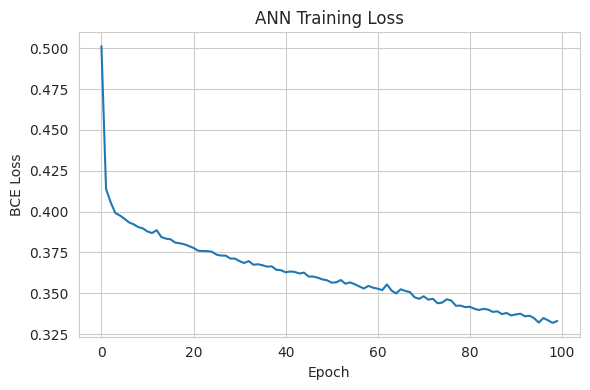

In [18]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.title('ANN Training Loss')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.tight_layout(); plt.show()


In [19]:
model.eval()
with torch.no_grad():
    ann_probs = model(X_test_t).numpy().flatten()
ann_preds = (ann_probs >= 0.5).astype(int)
print("Sample predicted probabilities:", ann_probs[:5])


Sample predicted probabilities: [0.20725808 0.6333603  0.04661213 0.39806595 0.01859361]


## Task 4: Comparison with Two Classical ML Models
Using **Logistic Regression** and **Random Forest**.

In [20]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)
lr_preds = log_reg.predict(X_test)


In [21]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


## Task 5: Performance Evaluation

In [22]:
def evaluate(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate(y_test, ann_preds, 'ANN'),
    evaluate(y_test, lr_preds, 'Logistic Regression'),
    evaluate(y_test, rf_preds, 'Random Forest'),
]).set_index('Model').round(3)

results


,Accuracy,Precision,Recall,F1-score
Model,,,,
ANN,0.786,0.619,0.500,0.553
Logistic Regression,0.803,0.646,0.575,0.608
Random Forest,0.795,0.639,0.521,0.574


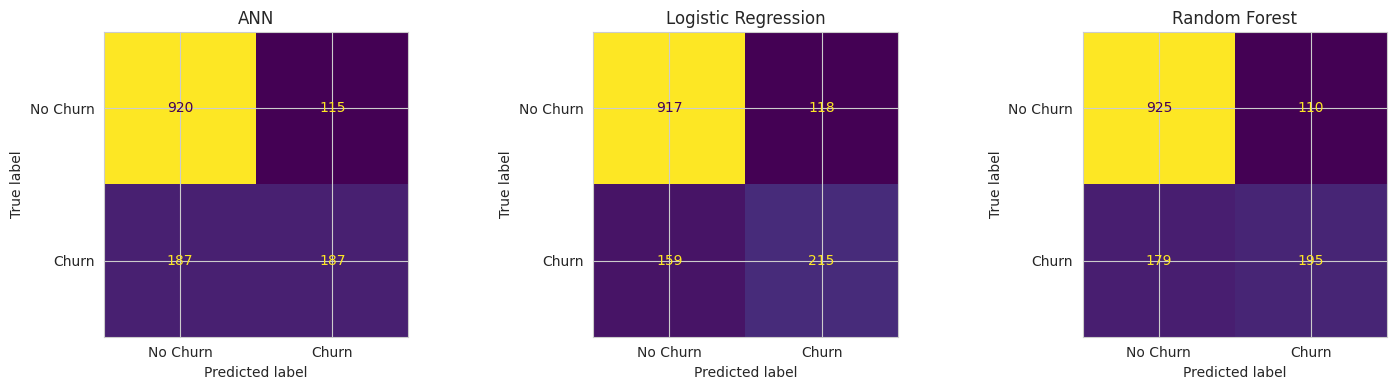

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, preds, name in zip(axes, [ann_preds, lr_preds, rf_preds], ['ANN', 'Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()


## Task 6: Analysis

In [24]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feat_imp.head(10)


Total Charges                      0.158946
Tenure Months                      0.149139
Monthly Charges                    0.133363
CLTV                               0.124499
Internet Service_Fiber optic       0.041760
Payment Method_Electronic check    0.036445
Dependents_Yes                     0.035573
Contract_Two year                  0.029826
Gender_Male                        0.022527
Online Security_Yes                0.022440
dtype: float64

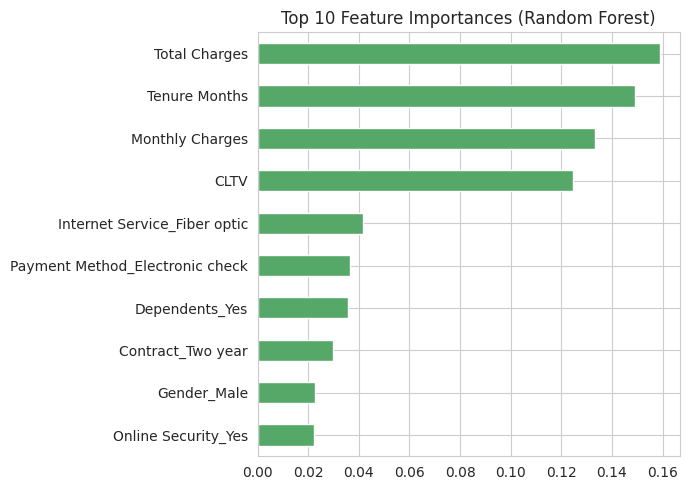

In [25]:
fig, ax = plt.subplots(figsize=(7,5))
feat_imp.head(10).sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout(); plt.show()


**1. Which model provides the best overall performance?**
**Logistic Regression** — it had the highest Accuracy, Precision, Recall, and F1-score of the three. The ANN and Random Forest performed similarly to each other, both slightly behind. On a dataset this size (~7,000 rows, mostly one-hot categorical features), a simpler linear model is a strong fit, and the added complexity of the ANN and Random Forest didn't translate into better generalization here.

**2. Which model provides the highest Recall?**
**Logistic Regression** again had the highest Recall.

**3. Why is Recall particularly important for customer churn prediction?**
Recall tells you what fraction of customers who *actually* churn get correctly flagged. Missing a churner (false negative) means losing that customer's revenue with no chance to intervene, while flagging a loyal customer as at-risk (false positive) just costs a retention offer they didn't need. Since the churn classes are imbalanced (roughly 27% churn / 73% stay), Accuracy alone can be misleading — a model that never predicts churn would still score around 73% accuracy while catching zero at-risk customers. Recall is the metric that actually reflects business cost here.

**4. Which customer characteristics appear to be associated with higher churn?**
The Random Forest importances point to **Total Charges, Tenure Months, Monthly Charges, and CLTV** as the strongest predictors — customers who are newer (low tenure), paying more per month, and therefore have accumulated less Total Charges are the highest-risk group. CLTV is also negatively correlated with churn, meaning higher lifetime-value customers churn less. Beyond the numeric fields, **fiber optic internet**, **electronic check payment**, and **month-to-month contracts** (visible in the EDA plots) are the categorical factors most associated with churn.

**5. What practical action could a telecom company take using the prediction results?**
Use the model's churn probability to power a **proactive retention program**: prioritize outreach toward new, high-paying, month-to-month customers on fiber optic plans paying by electronic check — the highest-risk segment identified above. Offer them incentives (discounted long-term contracts, bundled services) before they churn, rather than reacting after they've already left. CLTV can help prioritize *which* at-risk customers are worth the retention spend.